# Forecast Model Comparison vs NWS Daily Recorded High

Comparing all available forecast models against the official NWS daily recorded high temperature (Kalshi settlement value):

**NWP Models:** GFS, ECMWF, ICON, GEM, JMA, HRRR, NWP Ensemble Mean  
**Neural Net Models:** Model 1 (Forecast Bias-Correction), Model 2 (Historical/Regime), Model 3 (Market), Ensemble

In [1]:
import os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import config as cfg
import data_fetch

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.facecolor"] = "white"

# ── Load data ────────────────────────────────────────────────────────
nws = data_fetch.load_nws_daily()
nws["date"] = pd.to_datetime(nws["date"])

forecasts = data_fetch.load_forecasts()
forecasts["date"] = pd.to_datetime(forecasts["date"])

hrrr = pd.read_csv(os.path.join(cfg.DATA_DIR, "weather_forecasts", "hrrr_forecasts.csv"), parse_dates=["date"])

# Merge everything
df = nws.merge(forecasts, on=["date", "ticker"], how="inner")
df = df.merge(hrrr[["date", "ticker", "fcst_hrrr"]], on=["date", "ticker"], how="left")

# Fill NaN forecasts per city
fcst_cols = [c for c in df.columns if c.startswith("fcst_")]
for col in fcst_cols:
    city_means = df.groupby("ticker")[col].transform("mean")
    df[col] = df[col].fillna(city_means)
df["fcst_nwp_mean"] = df[[c for c in fcst_cols if c != "fcst_hrrr"]].mean(axis=1)
df = df.dropna(subset=["nws_high"]).reset_index(drop=True)

# Add city name
df["city"] = df["ticker"].map({t: cfg.CITIES[t][0] for t in cfg.CITY_TICKERS})

# ── Load NN predictions ──────────────────────────────────────────────
ckpt = cfg.CHECKPOINT_DIR
nn_preds = {}
for name, fn, mu_col in [
    ("NN Model 1\n(Forecast)", "model1_preds_test.csv", "mu"),
    ("NN Model 2\n(Historical)", "model2_preds_test.csv", "mu"),
    ("NN Model 3\n(Market)", "model3_preds_test.csv", "mu"),
    ("NN Ensemble", "ensemble_preds_test.csv", "ensemble_mu"),
]:
    path = os.path.join(ckpt, fn)
    if os.path.exists(path):
        p = pd.read_csv(path, parse_dates=["date"])
        p = p.rename(columns={mu_col: "mu_pred"})
        nn_preds[name] = p

nn_preds_val = {}
for name, fn in [
    ("NN Model 1\n(Forecast)", "model1_preds_val.csv"),
    ("NN Model 2\n(Historical)", "model2_preds_val.csv"),
    ("NN Model 3\n(Market)", "model3_preds_val.csv"),
]:
    path = os.path.join(ckpt, fn)
    if os.path.exists(path):
        nn_preds_val[name] = pd.read_csv(path, parse_dates=["date"])

# ── Display names ─────────────────────────────────────────────────────
NWP_NAMES = {
    "fcst_gfs_seamless": "GFS",
    "fcst_ecmwf_ifs025": "ECMWF",
    "fcst_icon_seamless": "ICON",
    "fcst_gem_seamless": "GEM",
    "fcst_jma_seamless": "JMA",
    "fcst_hrrr": "HRRR",
    "fcst_nwp_mean": "NWP Ens.\nMean",
}

ALL_NWP = list(NWP_NAMES.keys())

print(f"Total rows: {len(df):,}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Cities: {df['ticker'].nunique()}")
print(f"HRRR coverage: {df['fcst_hrrr'].notna().sum():,} / {len(df):,} rows")

Total rows: 31,339
Date range: 2022-01-01 to 2026-04-16
Cities: 20
HRRR coverage: 31,339 / 31,339 rows


In [2]:
# ── Helper: compute metrics ──────────────────────────────────────────

def metrics(y_true, y_pred):
    err = y_pred - y_true
    ae = np.abs(err)
    return {
        "MAE": np.mean(ae),
        "RMSE": np.sqrt(np.mean(err**2)),
        "Bias": np.mean(err),
        "Corr": np.corrcoef(y_true, y_pred)[0, 1] if len(y_true) > 1 else np.nan,
        "<=1F (%)": np.mean(ae <= 1) * 100,
        "<=2F (%)": np.mean(ae <= 2) * 100,
        "<=3F (%)": np.mean(ae <= 3) * 100,
        "P50": np.median(ae),
        "P90": np.percentile(ae, 90),
        "N": len(y_true),
    }


def build_summary(subset, label, include_nn_test=False, include_nn_val=False):
    """Build a summary DataFrame of all models on a given data subset."""
    rows = []
    yt = subset["nws_high"].values
    for col in ALL_NWP:
        mask = subset[col].notna()
        if mask.sum() < 10:
            continue
        m = metrics(subset.loc[mask, "nws_high"].values, subset.loc[mask, col].values)
        m["Model"] = NWP_NAMES[col]
        m["Type"] = "NWP"
        rows.append(m)

    if include_nn_test:
        for name, pred_df in nn_preds.items():
            merged = pred_df.merge(nws[["date", "ticker", "nws_high"]],
                                   on=["date", "ticker"], how="inner").dropna(subset=["nws_high", "mu_pred"])
            if len(merged) >= 10:
                m = metrics(merged["nws_high"].values, merged["mu_pred"].values)
                m["Model"] = name
                m["Type"] = "Neural Net"
                rows.append(m)

    if include_nn_val:
        for name, pred_df in nn_preds_val.items():
            merged = pred_df.merge(nws[["date", "ticker", "nws_high"]],
                                   on=["date", "ticker"], how="inner").dropna(subset=["nws_high", "mu"])
            if len(merged) >= 10:
                m = metrics(merged["nws_high"].values, merged["mu"].values)
                m["Model"] = name
                m["Type"] = "Neural Net"
                rows.append(m)

    out = pd.DataFrame(rows)
    out = out.sort_values("MAE").reset_index(drop=True)
    out.index = out.index + 1
    out.index.name = "Rank"
    return out

## 1. Overall Rankings — Test Set (2026)
The test set is the out-of-sample period that matters most. NN models were trained on 2022-2024, validated on 2025, and evaluated here on 2026.

In [3]:
test = df[(df["date"] >= pd.Timestamp(cfg.TEST_START)) & (df["date"] <= pd.Timestamp(cfg.TEST_END))]
summary_test = build_summary(test, "Test (2026)", include_nn_test=True)
display_cols = ["Model", "Type", "MAE", "RMSE", "Bias", "Corr", "<=1F (%)", "<=2F (%)", "<=3F (%)", "P50", "P90", "N"]
summary_test[display_cols].style.format({
    "MAE": "{:.2f}", "RMSE": "{:.2f}", "Bias": "{:+.2f}", "Corr": "{:.4f}",
    "<=1F (%)": "{:.1f}", "<=2F (%)": "{:.1f}", "<=3F (%)": "{:.1f}",
    "P50": "{:.2f}", "P90": "{:.2f}", "N": "{:.0f}",
}).bar(subset=["MAE"], color="#ff9999", vmin=0).background_gradient(
    subset=["Corr"], cmap="Greens", vmin=0.97
)

,Model,Type,MAE,RMSE,Bias,Corr,<=1F (%),<=2F (%),<=3F (%),P50,P90,N
Rank,,,,,,,,,,,,
1,NN Ensemble,Neural Net,1.22,1.66,+0.03,0.9962,52.3,81.7,93.4,0.93,2.55,2120
2,NN Model 1 (Forecast),Neural Net,1.22,1.66,+0.03,0.9962,52.1,81.7,93.4,0.93,2.55,2120
3,GFS,NWP,1.76,2.49,-0.39,0.9916,42.3,69.1,84.2,1.30,3.80,2120
4,HRRR,NWP,1.77,2.49,-0.39,0.9916,42.3,69.1,84.2,1.30,3.80,2120
5,GEM,NWP,2.28,3.31,-0.43,0.9849,36.2,59.5,75.6,1.60,5.00,2120
6,NWP Ens. Mean,NWP,2.30,2.89,-1.64,0.9920,23.3,52.0,72.9,1.96,4.46,2120
7,ICON,NWP,2.30,3.40,-1.63,0.9874,31.1,57.7,74.9,1.70,4.60,2120
8,ECMWF,NWP,2.75,3.42,-2.06,0.9896,21.2,41.2,62.6,2.40,5.20,2120
9,NN Model 3 (Market),Neural Net,3.30,4.31,-2.06,0.9803,21.2,39.3,55.8,2.60,7.00,2120


## 2. MAE Bar Chart — All Models on Test Set

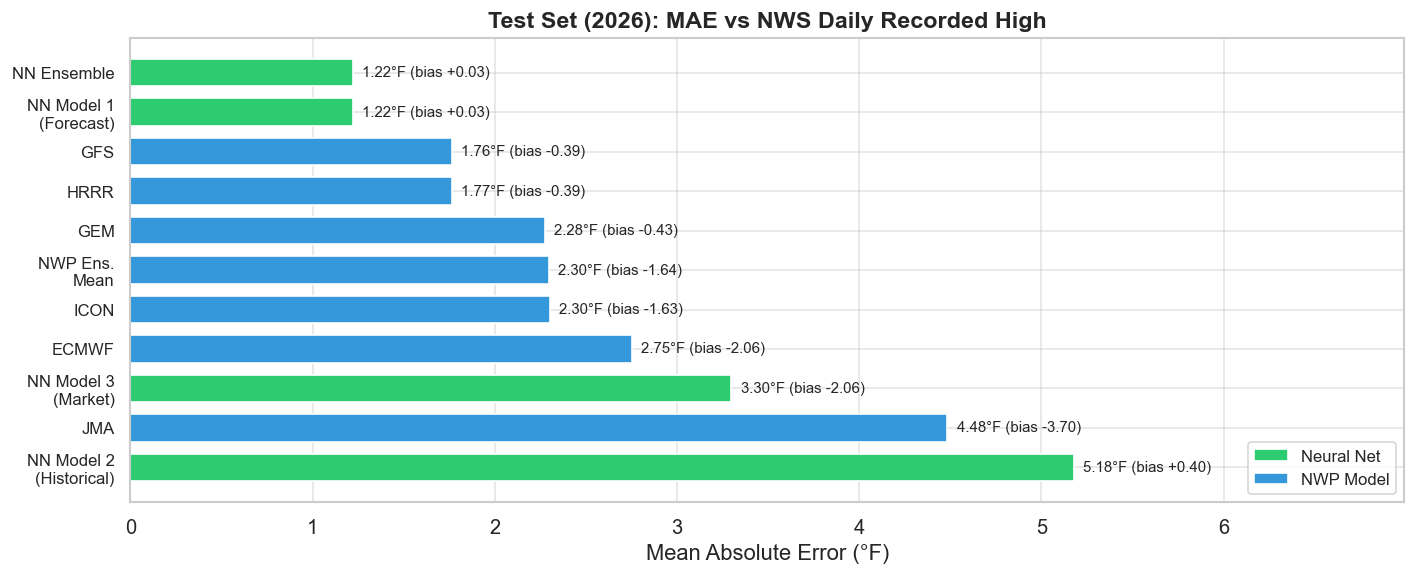

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
st = summary_test.sort_values("MAE")
colors = ["#2ecc71" if t == "Neural Net" else "#3498db" for t in st["Type"]]
bars = ax.barh(range(len(st)), st["MAE"], color=colors, edgecolor="white", height=0.7)
ax.set_yticks(range(len(st)))
ax.set_yticklabels(st["Model"], fontsize=10)
ax.set_xlabel("Mean Absolute Error (°F)")
ax.set_title("Test Set (2026): MAE vs NWS Daily Recorded High", fontsize=14, fontweight="bold")
ax.invert_yaxis()

for bar, mae, bias in zip(bars, st["MAE"], st["Bias"]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f"{mae:.2f}°F (bias {bias:+.2f})", va="center", fontsize=9)

ax.legend(handles=[
    plt.Rectangle((0,0),1,1, fc="#2ecc71", label="Neural Net"),
    plt.Rectangle((0,0),1,1, fc="#3498db", label="NWP Model"),
], loc="lower right", fontsize=10)
ax.set_xlim(0, st["MAE"].max() * 1.35)
plt.tight_layout()
plt.show()

## 3. Per-City MAE Heatmap — Test Set

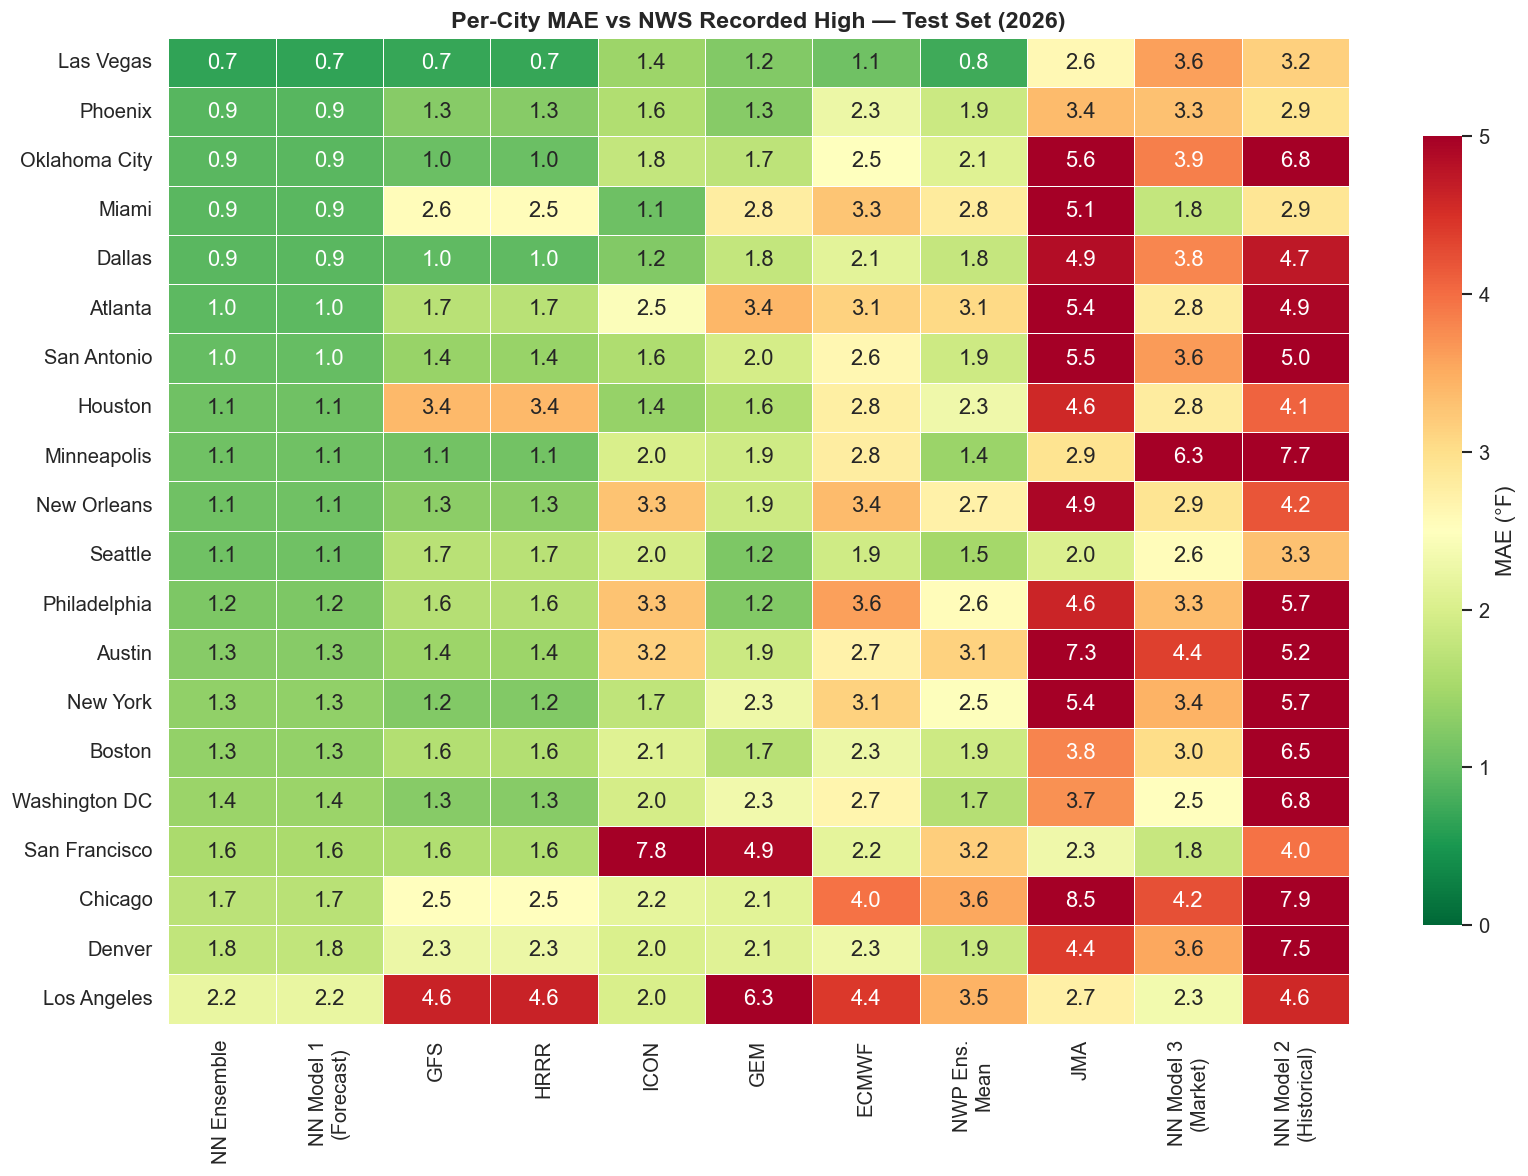

In [5]:
# Build per-city MAE matrix
model_order = ["NN Ensemble", "NN Model 1\n(Forecast)", "GFS", "HRRR", "ICON", "GEM",
               "ECMWF", "NWP Ens.\nMean", "JMA", "NN Model 3\n(Market)", "NN Model 2\n(Historical)"]

city_mae = {}
for ticker in sorted(cfg.CITY_TICKERS):
    city_name = cfg.CITIES[ticker][0]
    city_df = test[test["ticker"] == ticker]
    if len(city_df) == 0:
        continue
    row = {}
    for col in ALL_NWP:
        mask = city_df[col].notna()
        if mask.sum() > 0:
            row[NWP_NAMES[col]] = np.mean(np.abs(city_df.loc[mask, col] - city_df.loc[mask, "nws_high"]))
    for name, pred_df in nn_preds.items():
        merged = pred_df[pred_df["ticker"] == ticker].merge(
            nws[["date", "ticker", "nws_high"]], on=["date", "ticker"], how="inner"
        ).dropna(subset=["nws_high", "mu_pred"])
        if len(merged) > 0:
            row[name] = np.mean(np.abs(merged["mu_pred"] - merged["nws_high"]))
    city_mae[city_name] = row

mae_df = pd.DataFrame(city_mae).T
# Reorder columns to match model_order (only those that exist)
mae_df = mae_df[[c for c in model_order if c in mae_df.columns]]
# Sort cities by NN Ensemble MAE
if "NN Ensemble" in mae_df.columns:
    mae_df = mae_df.sort_values("NN Ensemble")

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(mae_df, annot=True, fmt=".1f", cmap="RdYlGn_r", ax=ax,
            linewidths=0.5, vmin=0, vmax=5,
            cbar_kws={"label": "MAE (°F)", "shrink": 0.8})
ax.set_title("Per-City MAE vs NWS Recorded High — Test Set (2026)", fontsize=14, fontweight="bold")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 4. Error Distributions — Test Set

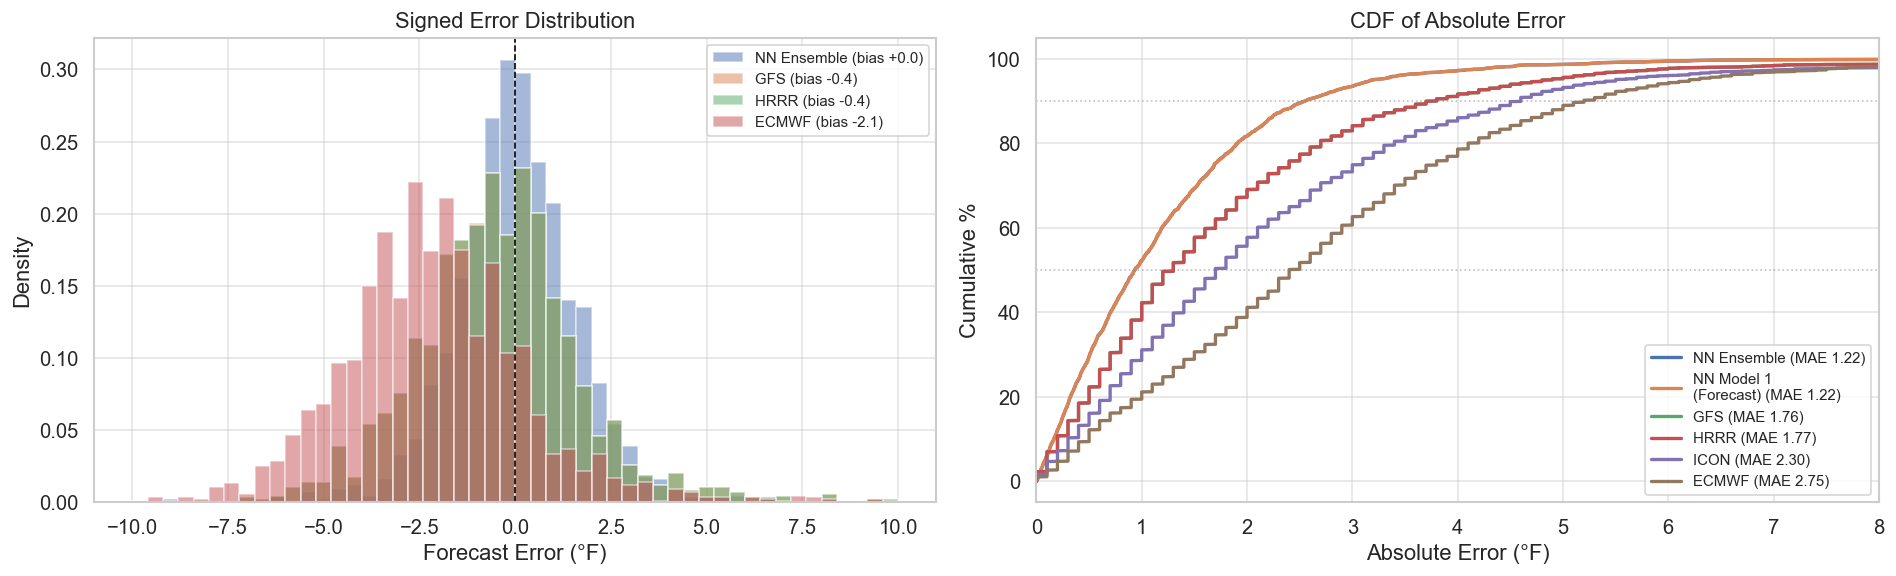

In [6]:
# Build error arrays for key models
key_models = {
    "NN Ensemble": None,
    "NN Model 1\n(Forecast)": None,
    "GFS": "fcst_gfs_seamless",
    "HRRR": "fcst_hrrr",
    "ICON": "fcst_icon_seamless",
    "ECMWF": "fcst_ecmwf_ifs025",
}

errors = {}
for name, col in key_models.items():
    if col:  # NWP model
        mask = test[col].notna()
        errors[name] = (test.loc[mask, col] - test.loc[mask, "nws_high"]).values
    elif name in nn_preds:
        merged = nn_preds[name].merge(nws[["date", "ticker", "nws_high"]],
                                       on=["date", "ticker"], how="inner").dropna(subset=["nws_high", "mu_pred"])
        errors[name] = (merged["mu_pred"] - merged["nws_high"]).values

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: histogram of signed errors
ax = axes[0]
for name in ["NN Ensemble", "GFS", "HRRR", "ECMWF"]:
    if name in errors:
        ax.hist(errors[name], bins=50, alpha=0.5, label=f"{name} (bias {np.mean(errors[name]):+.1f})",
                range=(-10, 10), density=True)
ax.axvline(0, color="black", ls="--", lw=1)
ax.set_xlabel("Forecast Error (°F)")
ax.set_ylabel("Density")
ax.set_title("Signed Error Distribution")
ax.legend(fontsize=9)

# Right: CDF of absolute errors
ax = axes[1]
for name in ["NN Ensemble", "NN Model 1\n(Forecast)", "GFS", "HRRR", "ICON", "ECMWF"]:
    if name in errors:
        ae = np.sort(np.abs(errors[name]))
        cdf = np.arange(1, len(ae)+1) / len(ae)
        ax.plot(ae, cdf * 100, label=f"{name} (MAE {np.mean(ae):.2f})", lw=2)
ax.axhline(90, color="gray", ls=":", lw=1, alpha=0.5)
ax.axhline(50, color="gray", ls=":", lw=1, alpha=0.5)
ax.set_xlabel("Absolute Error (°F)")
ax.set_ylabel("Cumulative %")
ax.set_title("CDF of Absolute Error")
ax.set_xlim(0, 8)
ax.legend(fontsize=9, loc="lower right")

plt.tight_layout()
plt.show()

## 5. Per-City Scatter: NN Ensemble vs GFS vs HRRR

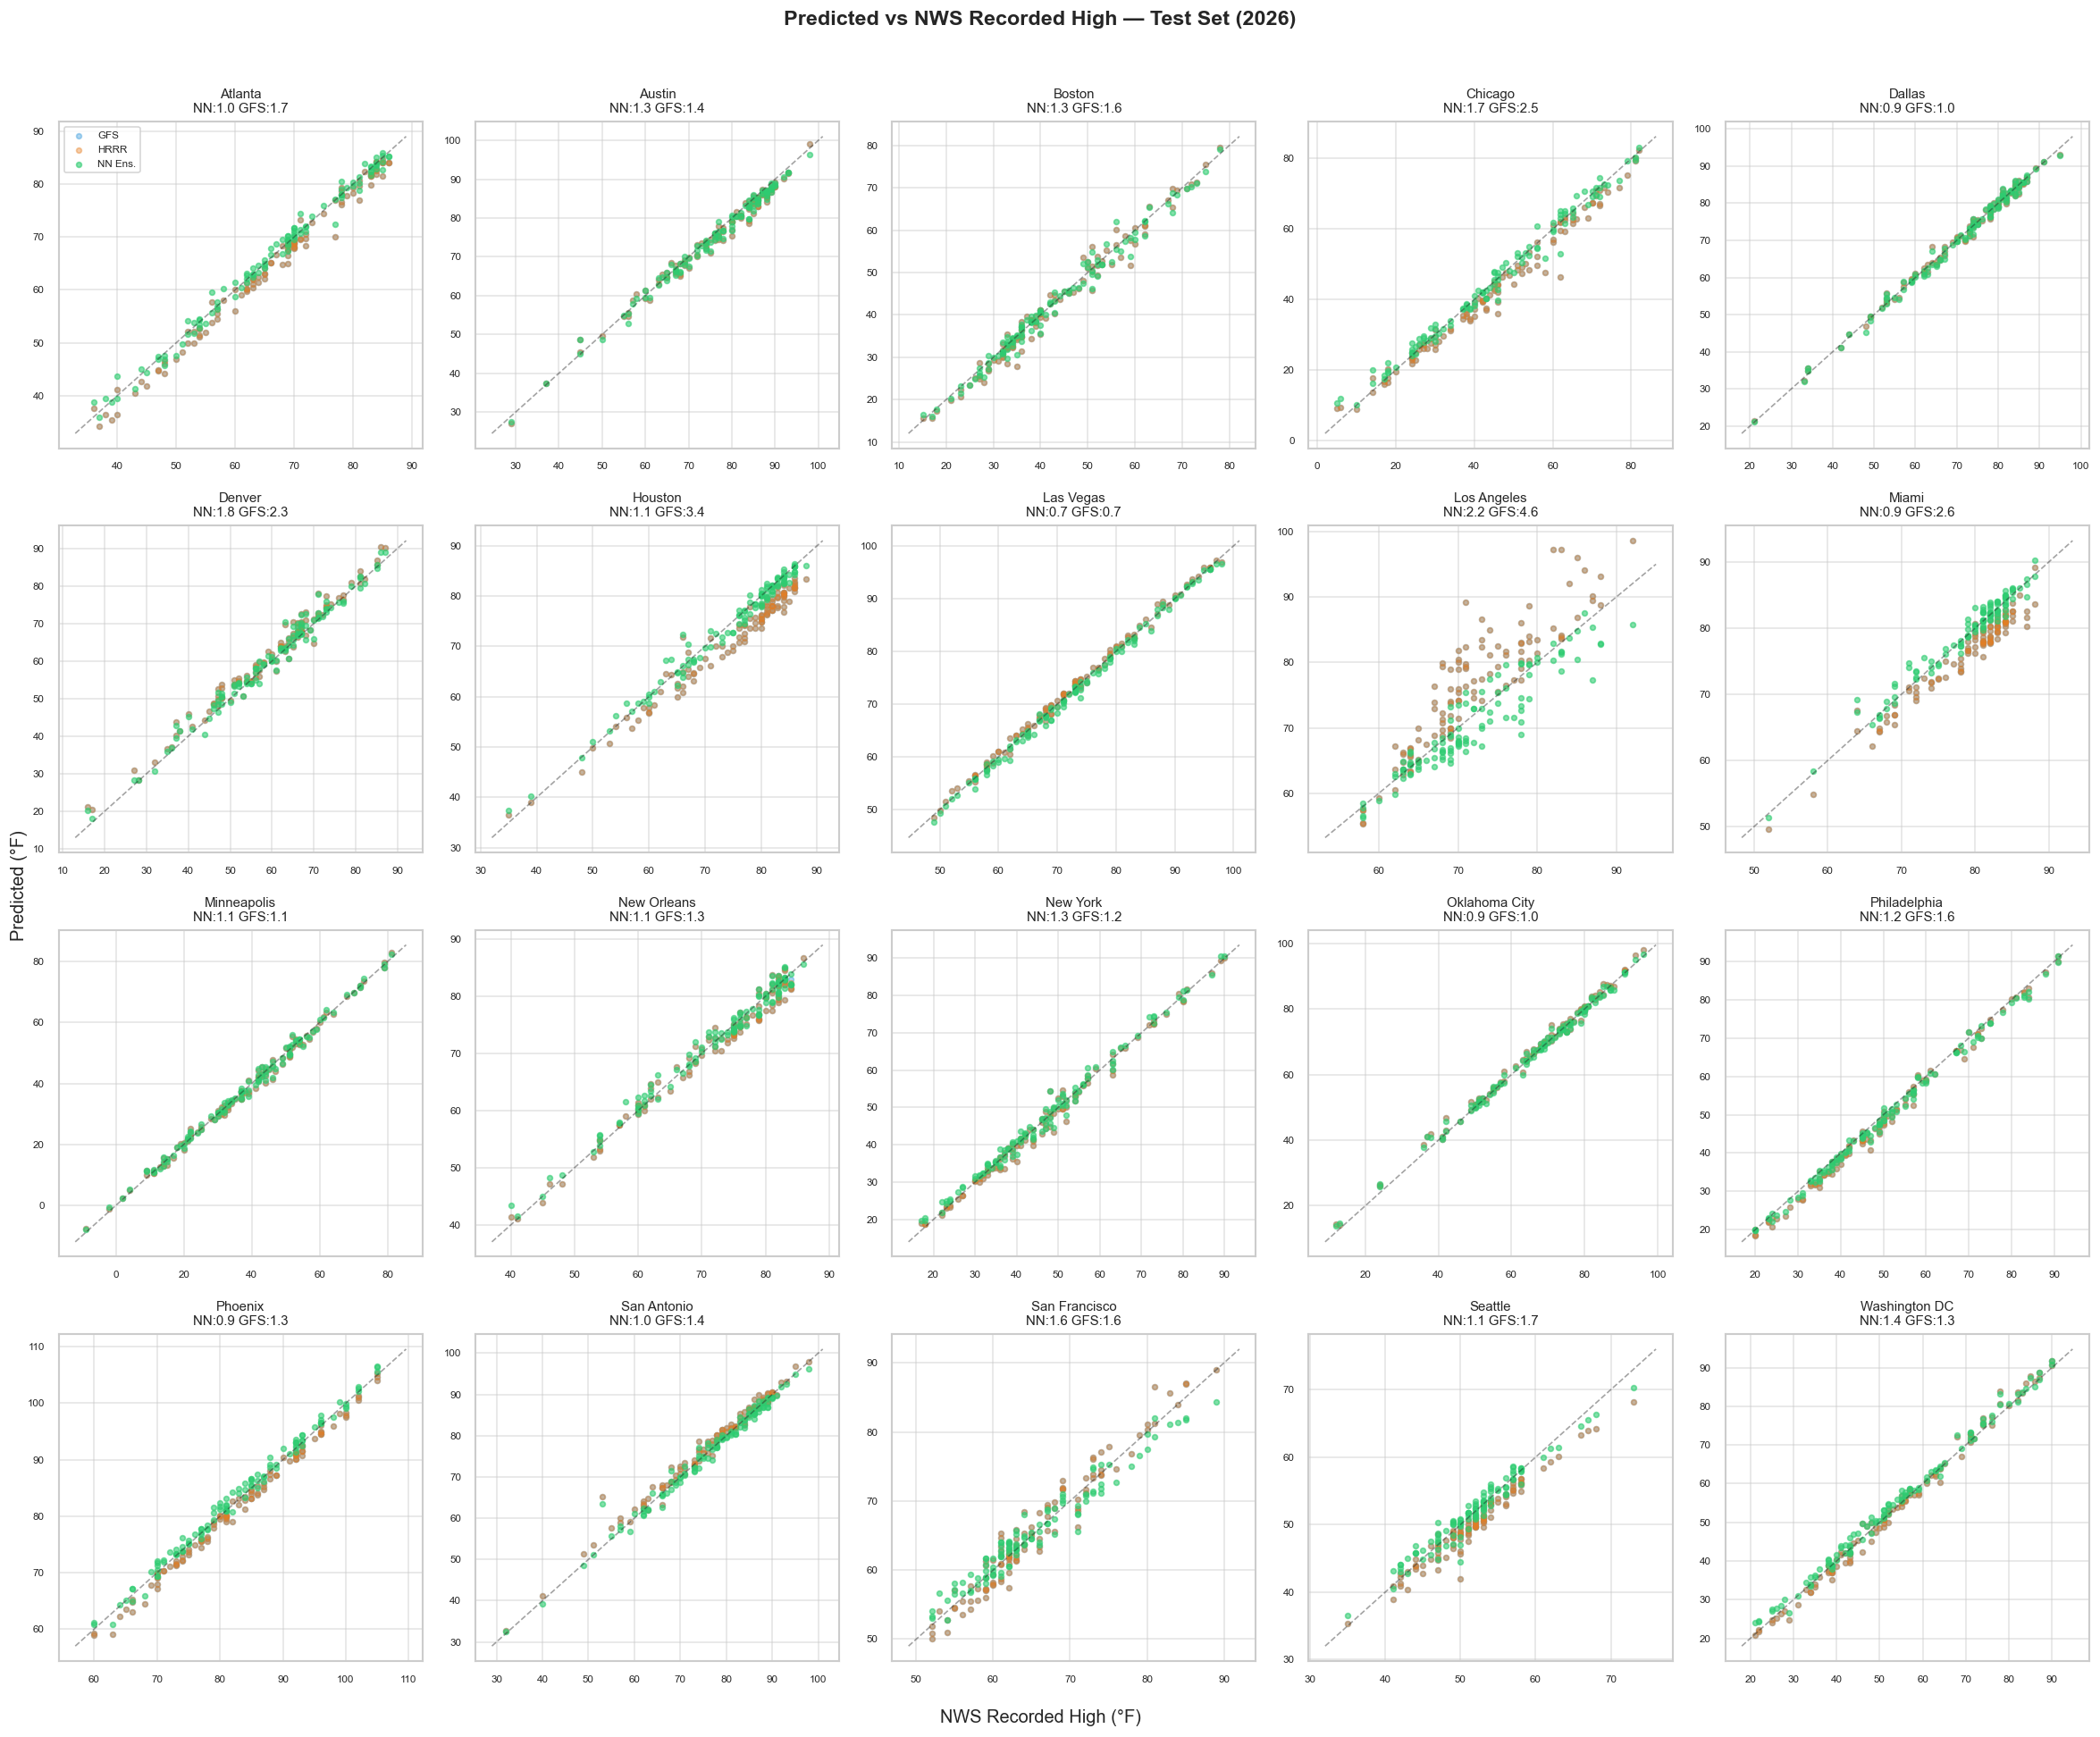

In [7]:
# NN Ensemble vs NWS scatter by city
ens_merged = nn_preds["NN Ensemble"].merge(
    nws[["date", "ticker", "nws_high"]], on=["date", "ticker"], how="inner"
).dropna(subset=["nws_high", "mu_pred"])
ens_merged["city"] = ens_merged["ticker"].map({t: cfg.CITIES[t][0] for t in cfg.CITY_TICKERS})

fig, axes = plt.subplots(4, 5, figsize=(20, 16), sharex=False, sharey=False)
axes = axes.flatten()

for i, city in enumerate(sorted(ens_merged["city"].unique())):
    ax = axes[i]
    city_data = ens_merged[ens_merged["city"] == city]
    city_test = test[test["city"] == city]

    # Plot perfect line
    lo = min(city_data["nws_high"].min(), city_data["mu_pred"].min()) - 3
    hi = max(city_data["nws_high"].max(), city_data["mu_pred"].max()) + 3
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, alpha=0.4)

    # GFS
    mask = city_test["fcst_gfs_seamless"].notna()
    ax.scatter(city_test.loc[mask, "nws_high"], city_test.loc[mask, "fcst_gfs_seamless"],
               s=12, alpha=0.4, c="#3498db", label="GFS")

    # HRRR
    mask_h = city_test["fcst_hrrr"].notna()
    if mask_h.sum() > 0:
        ax.scatter(city_test.loc[mask_h, "nws_high"], city_test.loc[mask_h, "fcst_hrrr"],
                   s=12, alpha=0.4, c="#e67e22", label="HRRR")

    # NN Ensemble
    ax.scatter(city_data["nws_high"], city_data["mu_pred"],
               s=12, alpha=0.6, c="#2ecc71", label="NN Ens.")

    m_nn = metrics(city_data["nws_high"].values, city_data["mu_pred"].values)
    m_gfs = metrics(city_test.loc[mask, "nws_high"].values, city_test.loc[mask, "fcst_gfs_seamless"].values)
    ax.set_title(f"{city}\nNN:{m_nn['MAE']:.1f} GFS:{m_gfs['MAE']:.1f}", fontsize=9)
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.legend(fontsize=7, loc="upper left")

fig.suptitle("Predicted vs NWS Recorded High — Test Set (2026)", fontsize=14, fontweight="bold", y=1.01)
fig.supxlabel("NWS Recorded High (°F)", fontsize=12)
fig.supylabel("Predicted (°F)", fontsize=12)
plt.tight_layout()
plt.show()

## 6. Rolling MAE Over Time — NN Ensemble vs GFS vs HRRR

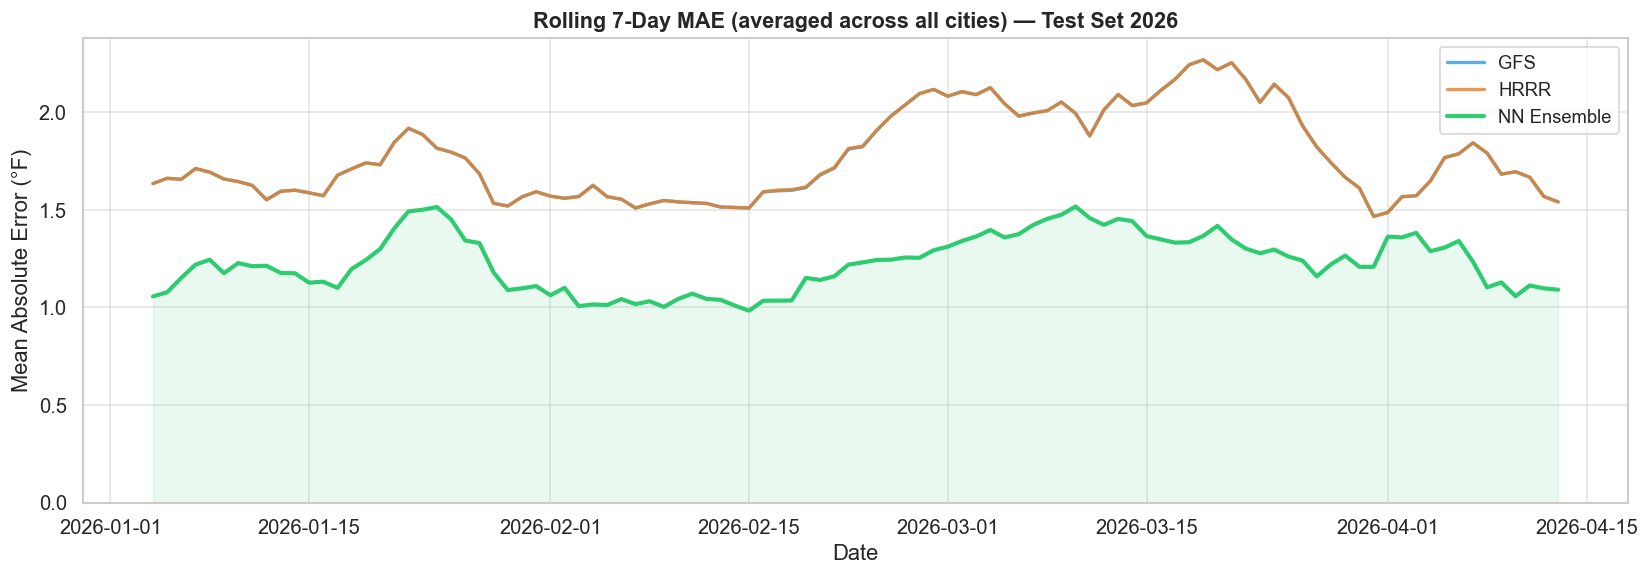

In [8]:
# Rolling 7-day MAE across all cities
ens_test = nn_preds["NN Ensemble"].merge(
    nws[["date", "ticker", "nws_high"]], on=["date", "ticker"], how="inner"
).dropna(subset=["nws_high", "mu_pred"])
ens_test["ae_nn"] = np.abs(ens_test["mu_pred"] - ens_test["nws_high"])

# GFS errors on same dates
gfs_test = test[["date", "ticker", "nws_high", "fcst_gfs_seamless", "fcst_hrrr"]].dropna(subset=["fcst_gfs_seamless"])
gfs_test["ae_gfs"] = np.abs(gfs_test["fcst_gfs_seamless"] - gfs_test["nws_high"])
gfs_test["ae_hrrr"] = np.abs(gfs_test["fcst_hrrr"] - gfs_test["nws_high"])

# Daily mean AE across cities
nn_daily = ens_test.groupby("date")["ae_nn"].mean()
gfs_daily = gfs_test.groupby("date")["ae_gfs"].mean()
hrrr_daily = gfs_test.dropna(subset=["fcst_hrrr"]).groupby("date")["ae_hrrr"].mean()

# 7-day rolling
window = 7
nn_roll = nn_daily.rolling(window, center=True).mean()
gfs_roll = gfs_daily.rolling(window, center=True).mean()
hrrr_roll = hrrr_daily.rolling(window, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(gfs_roll.index, gfs_roll.values, label="GFS", color="#3498db", lw=2, alpha=0.8)
ax.plot(hrrr_roll.index, hrrr_roll.values, label="HRRR", color="#e67e22", lw=2, alpha=0.8)
ax.plot(nn_roll.index, nn_roll.values, label="NN Ensemble", color="#2ecc71", lw=2.5)
ax.fill_between(nn_roll.index, 0, nn_roll.values, color="#2ecc71", alpha=0.1)
ax.set_xlabel("Date")
ax.set_ylabel("Mean Absolute Error (°F)")
ax.set_title(f"Rolling {window}-Day MAE (averaged across all cities) — Test Set 2026",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

## 7. Seasonal / Monthly Breakdown

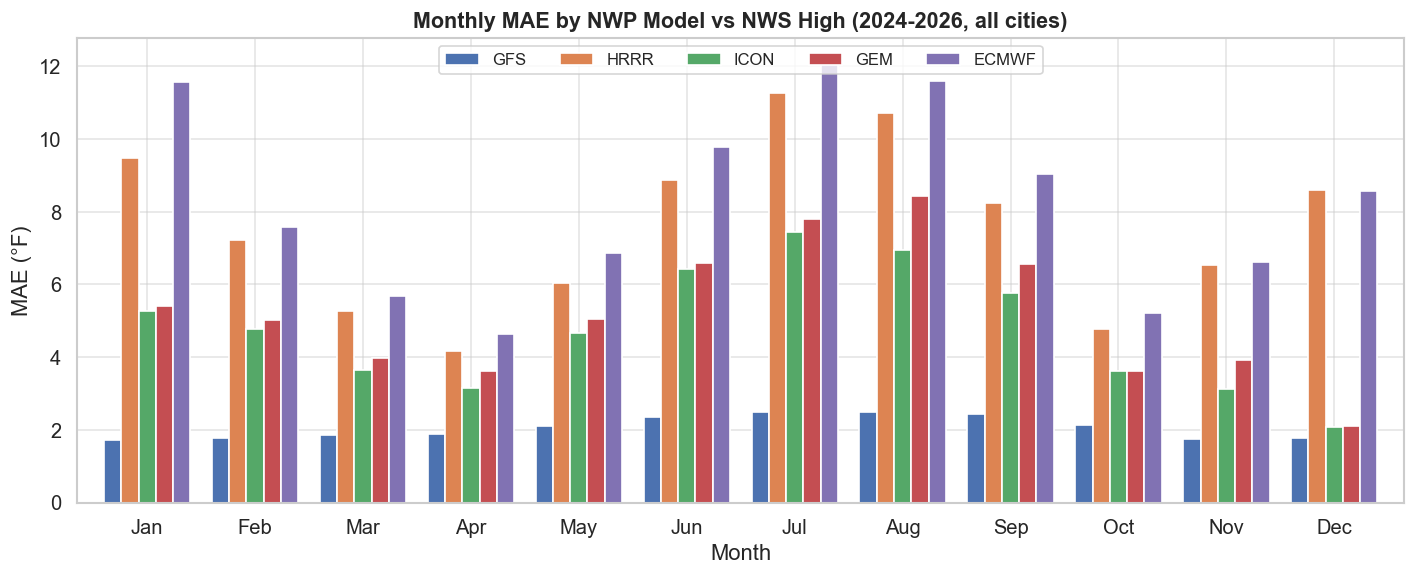

In [9]:
# Monthly MAE for key models on full dataset (where HRRR is available: 2024+)
df_hrrr = df[df["fcst_hrrr"].notna()].copy()
df_hrrr["month"] = df_hrrr["date"].dt.month
df_hrrr["month_name"] = df_hrrr["date"].dt.strftime("%b")

monthly_models = {
    "GFS": "fcst_gfs_seamless",
    "HRRR": "fcst_hrrr",
    "ICON": "fcst_icon_seamless",
    "GEM": "fcst_gem_seamless",
    "ECMWF": "fcst_ecmwf_ifs025",
}

monthly_data = []
for name, col in monthly_models.items():
    for month in sorted(df_hrrr["month"].unique()):
        mdf = df_hrrr[df_hrrr["month"] == month]
        mask = mdf[col].notna()
        if mask.sum() > 0:
            mae = np.mean(np.abs(mdf.loc[mask, col] - mdf.loc[mask, "nws_high"]))
            monthly_data.append({"Model": name, "Month": month,
                                "Month_Name": mdf["month_name"].iloc[0], "MAE": mae})

monthly_df = pd.DataFrame(monthly_data)
pivot = monthly_df.pivot(index="Month", columns="Model", values="MAE")
pivot.index = [["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"][m-1]
               for m in pivot.index]

fig, ax = plt.subplots(figsize=(12, 5))
pivot[["GFS", "HRRR", "ICON", "GEM", "ECMWF"]].plot(
    kind="bar", ax=ax, width=0.8, edgecolor="white"
)
ax.set_xlabel("Month")
ax.set_ylabel("MAE (°F)")
ax.set_title("Monthly MAE by NWP Model vs NWS High (2024-2026, all cities)", fontsize=13, fontweight="bold")
ax.legend(fontsize=10, ncol=5, loc="upper center")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

## 8. NN Ensemble Improvement Over GFS by City

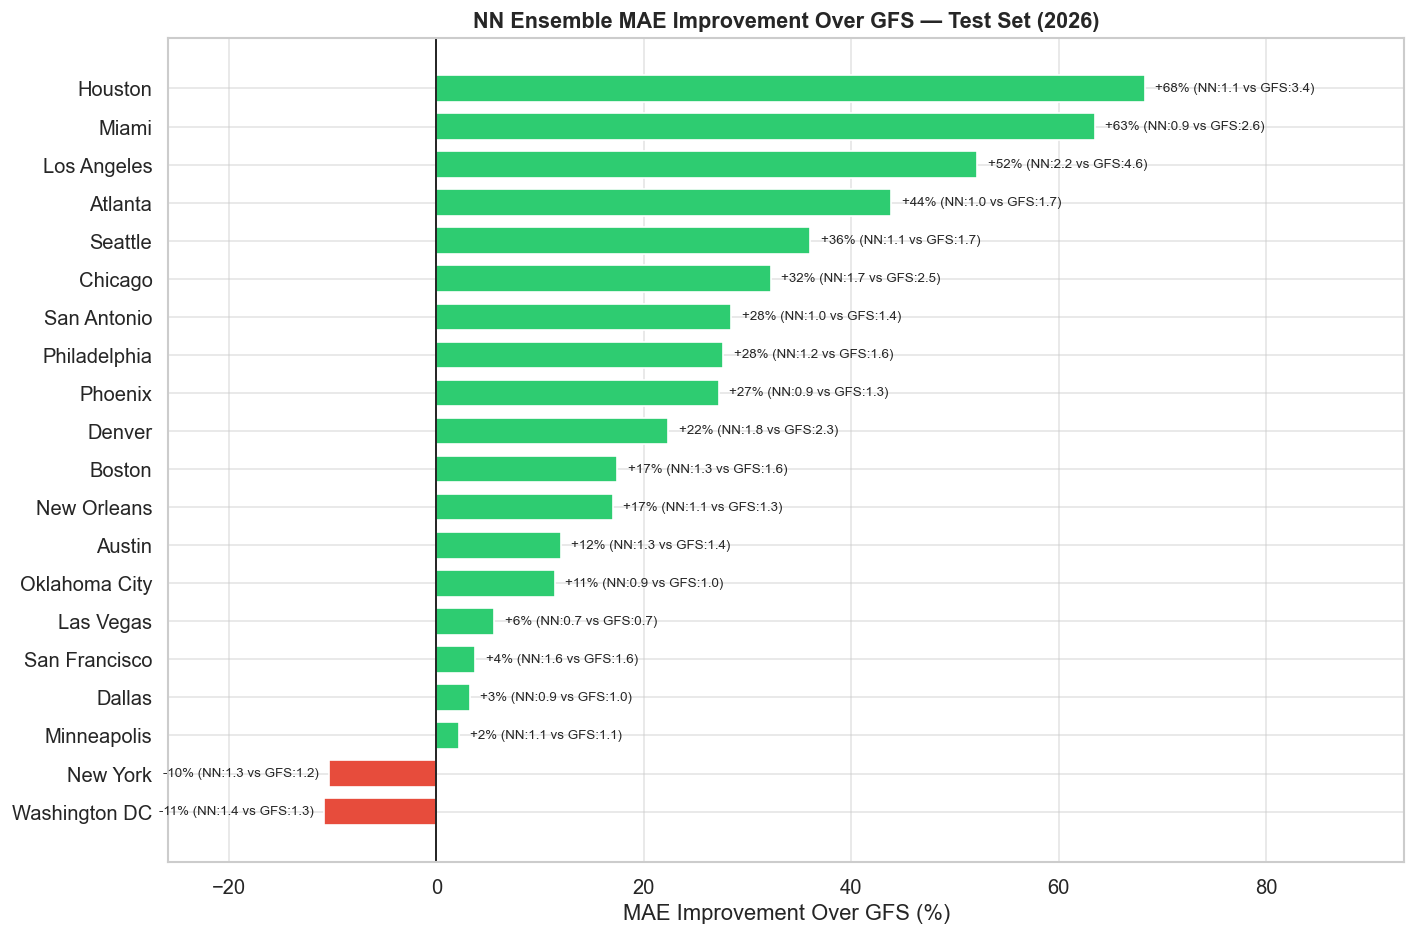

In [10]:
# Compute MAE improvement of NN Ensemble over GFS per city
improvement = []
for ticker in sorted(cfg.CITY_TICKERS):
    city_name = cfg.CITIES[ticker][0]
    city_test_df = test[test["ticker"] == ticker]

    # GFS MAE
    mask = city_test_df["fcst_gfs_seamless"].notna()
    gfs_mae = np.mean(np.abs(city_test_df.loc[mask, "fcst_gfs_seamless"] - city_test_df.loc[mask, "nws_high"]))

    # HRRR MAE
    mask_h = city_test_df["fcst_hrrr"].notna()
    hrrr_mae = np.mean(np.abs(city_test_df.loc[mask_h, "fcst_hrrr"] - city_test_df.loc[mask_h, "nws_high"])) if mask_h.sum() > 0 else np.nan

    # NN Ensemble MAE
    ens = nn_preds["NN Ensemble"]
    city_ens = ens[ens["ticker"] == ticker].merge(
        nws[["date", "ticker", "nws_high"]], on=["date", "ticker"], how="inner"
    ).dropna(subset=["nws_high", "mu_pred"])
    nn_mae = np.mean(np.abs(city_ens["mu_pred"] - city_ens["nws_high"])) if len(city_ens) > 0 else np.nan

    improvement.append({
        "City": city_name,
        "GFS MAE": gfs_mae,
        "HRRR MAE": hrrr_mae,
        "NN MAE": nn_mae,
        "vs GFS": (gfs_mae - nn_mae) / gfs_mae * 100 if not np.isnan(nn_mae) else np.nan,
        "vs HRRR": (hrrr_mae - nn_mae) / hrrr_mae * 100 if not np.isnan(hrrr_mae) and not np.isnan(nn_mae) else np.nan,
    })

imp_df = pd.DataFrame(improvement).sort_values("vs GFS", ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in imp_df["vs GFS"]]
bars = ax.barh(range(len(imp_df)), imp_df["vs GFS"], color=colors, edgecolor="white", height=0.7)
ax.set_yticks(range(len(imp_df)))
ax.set_yticklabels(imp_df["City"])
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("MAE Improvement Over GFS (%)")
ax.set_title("NN Ensemble MAE Improvement Over GFS — Test Set (2026)", fontsize=13, fontweight="bold")
ax.invert_yaxis()

for bar, pct, nn, gfs in zip(bars, imp_df["vs GFS"], imp_df["NN MAE"], imp_df["GFS MAE"]):
    ax.text(bar.get_width() + 1 if bar.get_width() >= 0 else bar.get_width() - 1,
            bar.get_y() + bar.get_height()/2,
            f"{pct:+.0f}% (NN:{nn:.1f} vs GFS:{gfs:.1f})",
            va="center", fontsize=8,
            ha="left" if bar.get_width() >= 0 else "right")

ax.set_xlim(min(imp_df["vs GFS"].min() - 15, -10), imp_df["vs GFS"].max() + 25)
plt.tight_layout()
plt.show()

## 9. Validation Set Rankings (2025)
Shows how models performed on the validation period (used for ensemble weight training).

In [11]:
val = df[(df["date"] >= pd.Timestamp(cfg.VAL_START)) & (df["date"] <= pd.Timestamp(cfg.VAL_END))]
summary_val = build_summary(val, "Val (2025)", include_nn_val=True)
summary_val[display_cols].style.format({
    "MAE": "{:.2f}", "RMSE": "{:.2f}", "Bias": "{:+.2f}", "Corr": "{:.4f}",
    "<=1F (%)": "{:.1f}", "<=2F (%)": "{:.1f}", "<=3F (%)": "{:.1f}",
    "P50": "{:.2f}", "P90": "{:.2f}", "N": "{:.0f}",
}).bar(subset=["MAE"], color="#ff9999", vmin=0)

,Model,Type,MAE,RMSE,Bias,Corr,<=1F (%),<=2F (%),<=3F (%),P50,P90,N
Rank,,,,,,,,,,,,
1,NN Model 1 (Forecast),Neural Net,1.08,1.46,-0.03,0.9970,57.8,85.9,95.6,0.84,2.28,7300
2,GFS,NWP,2.07,2.96,-0.55,0.9880,37.6,63.8,79.3,1.50,4.50,7300
3,HRRR,NWP,2.07,2.96,-0.55,0.9880,37.5,63.8,79.3,1.50,4.50,7300
4,ICON,NWP,2.34,3.25,-1.57,0.9885,30.9,55.6,74.4,1.80,4.70,7300
5,NWP Ens. Mean,NWP,2.39,3.07,-1.60,0.9902,25.7,49.8,69.5,2.02,4.70,7300
6,GEM,NWP,2.52,3.50,-0.58,0.9831,30.2,53.6,70.7,1.90,5.40,7300
7,NN Model 3 (Market),Neural Net,2.69,3.56,-0.00,0.9855,26.3,47.8,64.9,2.11,5.72,7300
8,ECMWF,NWP,2.85,3.64,-1.95,0.9867,21.6,42.7,62.4,2.40,5.60,7300
9,NN Model 2 (Historical),Neural Net,4.15,5.72,+0.55,0.9531,19.9,36.4,50.5,2.97,9.35,7300


## 10. Per-City Bias Heatmap
Shows which models systematically over/under-predict in each city. Blue = cold bias, red = warm bias.

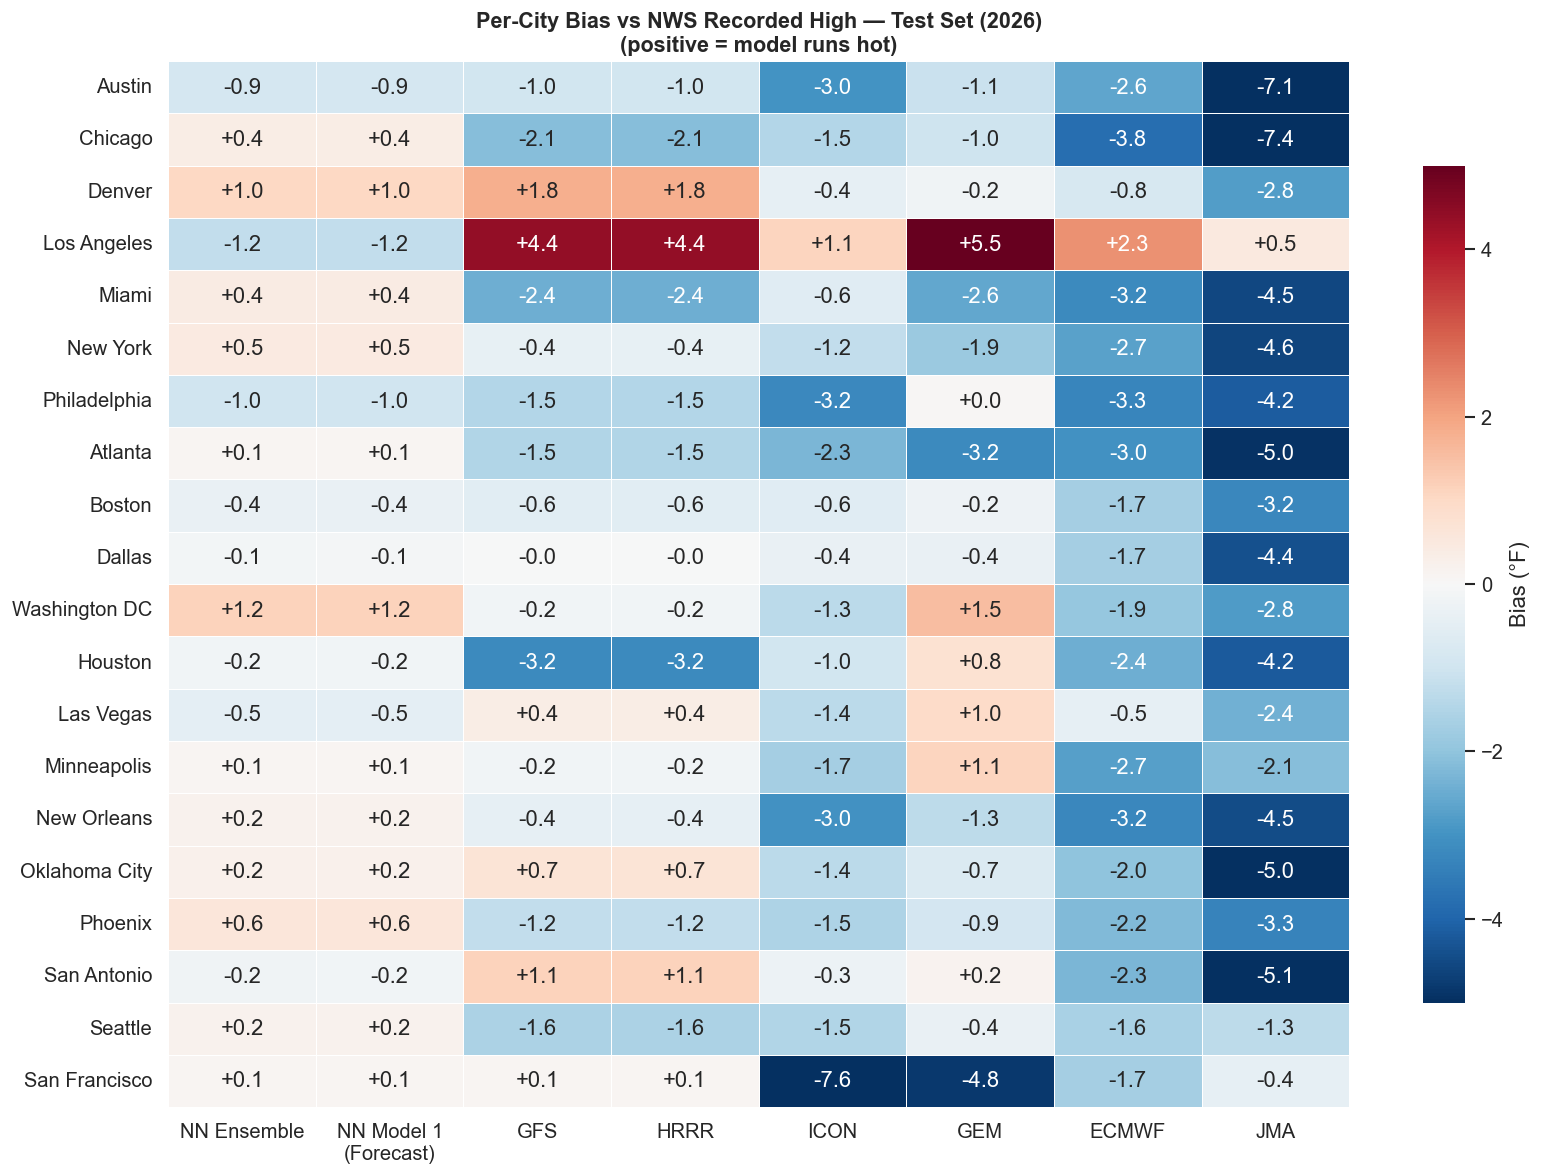

In [12]:
# Per-city bias matrix on test set
bias_order = ["NN Ensemble", "NN Model 1\n(Forecast)", "GFS", "HRRR", "ICON", "GEM", "ECMWF", "JMA"]

city_bias = {}
for ticker in sorted(cfg.CITY_TICKERS):
    city_name = cfg.CITIES[ticker][0]
    city_df = test[test["ticker"] == ticker]
    if len(city_df) == 0:
        continue
    row = {}
    for col in ALL_NWP:
        mask = city_df[col].notna()
        if mask.sum() > 0:
            row[NWP_NAMES[col]] = np.mean(city_df.loc[mask, col] - city_df.loc[mask, "nws_high"])
    for name, pred_df in nn_preds.items():
        merged = pred_df[pred_df["ticker"] == ticker].merge(
            nws[["date", "ticker", "nws_high"]], on=["date", "ticker"], how="inner"
        ).dropna(subset=["nws_high", "mu_pred"])
        if len(merged) > 0:
            row[name] = np.mean(merged["mu_pred"] - merged["nws_high"])
    city_bias[city_name] = row

bias_df = pd.DataFrame(city_bias).T
bias_df = bias_df[[c for c in bias_order if c in bias_df.columns]]

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(bias_df, annot=True, fmt="+.1f", cmap="RdBu_r", center=0, ax=ax,
            linewidths=0.5, vmin=-5, vmax=5,
            cbar_kws={"label": "Bias (°F)", "shrink": 0.8})
ax.set_title("Per-City Bias vs NWS Recorded High — Test Set (2026)\n(positive = model runs hot)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 11. Head-to-Head: NN Ensemble Wins vs GFS
For each city-day, which model was closer to the NWS recorded high?

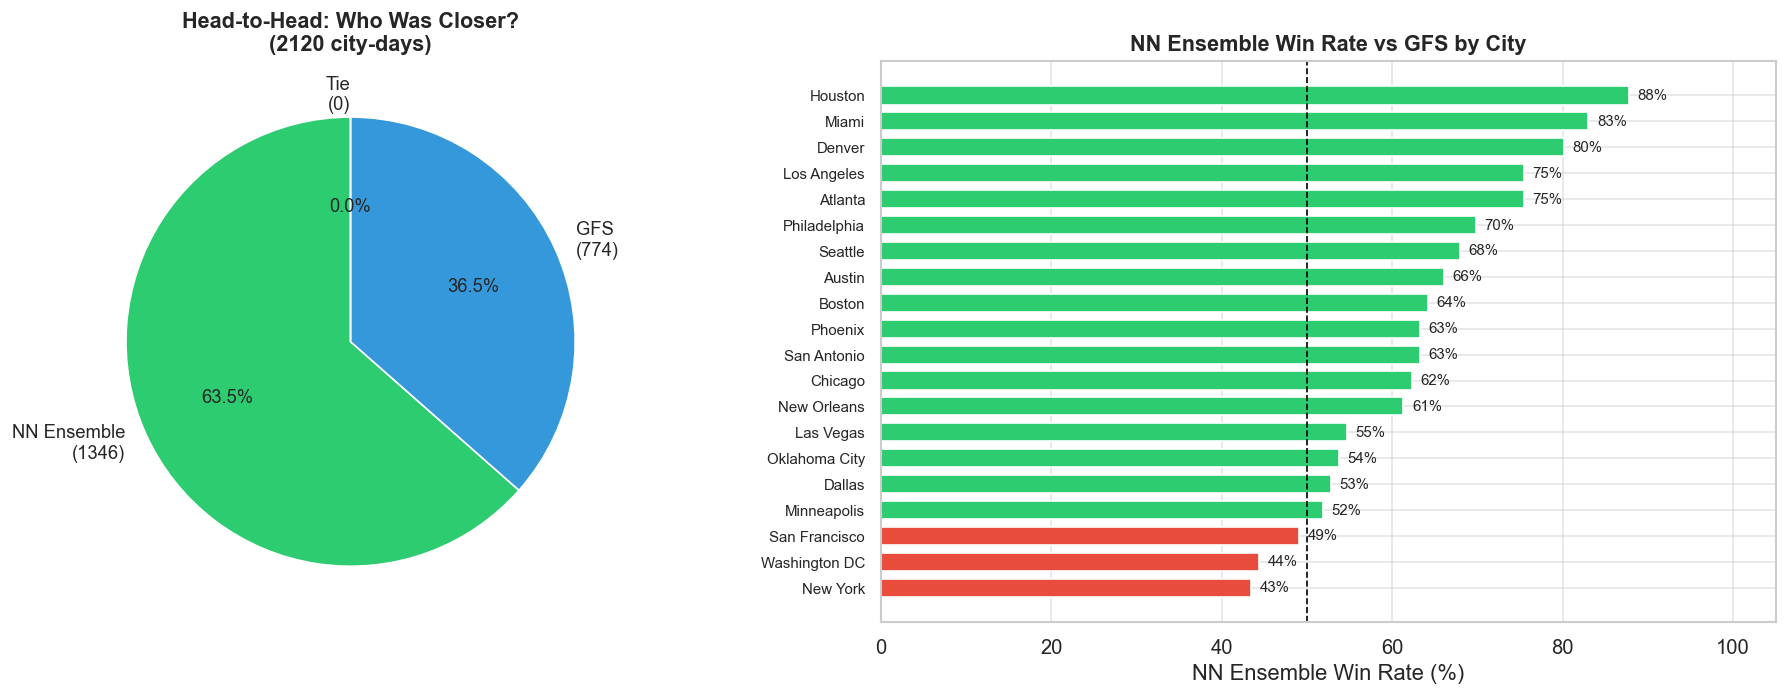

In [13]:
# Head-to-head: per city-day, was NN or GFS closer?
h2h = nn_preds["NN Ensemble"].merge(
    nws[["date", "ticker", "nws_high"]], on=["date", "ticker"], how="inner"
).merge(
    test[["date", "ticker", "fcst_gfs_seamless", "fcst_hrrr"]], on=["date", "ticker"], how="inner"
).dropna(subset=["nws_high", "mu_pred", "fcst_gfs_seamless"])

h2h["ae_nn"] = np.abs(h2h["mu_pred"] - h2h["nws_high"])
h2h["ae_gfs"] = np.abs(h2h["fcst_gfs_seamless"] - h2h["nws_high"])
h2h["nn_wins"] = h2h["ae_nn"] < h2h["ae_gfs"]
h2h["tie"] = h2h["ae_nn"] == h2h["ae_gfs"]
h2h["city"] = h2h["ticker"].map({t: cfg.CITIES[t][0] for t in cfg.CITY_TICKERS})

# Overall
nn_w = h2h["nn_wins"].sum()
gfs_w = (~h2h["nn_wins"] & ~h2h["tie"]).sum()
ties = h2h["tie"].sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart
ax = axes[0]
ax.pie([nn_w, gfs_w, ties], labels=[f"NN Ensemble\n({nn_w})", f"GFS\n({gfs_w})", f"Tie\n({ties})"],
       colors=["#2ecc71", "#3498db", "#bdc3c7"], autopct="%1.1f%%", startangle=90,
       textprops={"fontsize": 11})
ax.set_title(f"Head-to-Head: Who Was Closer?\n({len(h2h)} city-days)", fontsize=13, fontweight="bold")

# Per-city win rate
ax = axes[1]
city_wins = h2h.groupby("city")["nn_wins"].mean().sort_values(ascending=True) * 100
colors = ["#2ecc71" if v > 50 else "#e74c3c" for v in city_wins]
ax.barh(range(len(city_wins)), city_wins, color=colors, edgecolor="white", height=0.7)
ax.set_yticks(range(len(city_wins)))
ax.set_yticklabels(city_wins.index, fontsize=9)
ax.axvline(50, color="black", ls="--", lw=1)
ax.set_xlabel("NN Ensemble Win Rate (%)")
ax.set_title("NN Ensemble Win Rate vs GFS by City", fontsize=13, fontweight="bold")
for i, v in enumerate(city_wins):
    ax.text(v + 1, i, f"{v:.0f}%", va="center", fontsize=9)
ax.set_xlim(0, 105)

plt.tight_layout()
plt.show()